<a target="_blank" href="https://colab.research.google.com/github/fintech-dl-hse/course/blob/main/seminars/09_rnn_transformer/08_seminar_rnn_transformer.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# RNN и Transformer

### Структура

- Recap: NLP, эмбэддинги
- `nn.Embedding`
- RNN: PyTorch API, своя реализация
- LSTM, GRU
- Transformer: Attention, Masked Attention, Multi-Head Attention
- Positional Embeddings: Learned, Sinusoidal, RoPE
- Efficient Attention
- HuggingFace: Pipeline, Auto* Classes, Training
- Блиц
- Домашки

## Recap

На прошлом семинаре мы разобрали основы NLP: Word2Vec, FastText, токенизацию (BPE, WordPiece). Домашка `tokenization` была посвящена этим темам.

На лекции этой недели мы рассмотрели рекуррентные сети, механизм внимания и архитектуру Transformer. Сегодня закрепим это на практике.

### Векторные представления

#### ❓ **Вопрос**: что нужно сделать, чтобы получить векторные представления слов?

<details>

<summary><strong>Ответ</strong></summary>

1. Собрать словарь (или обучить токенизатор)</br>
2. Каждому токену присвоить индекс</br>
3. Создать матрицу эмбэддингов `nn.Embedding(vocab_size, emb_dim)`</br>
4. По индексу токена получить соответствующий вектор из матрицы</br>

</details>

#### ❓ **Вопрос**: как происходит преобразование текста в эмбэддинги?

<details>

<summary><strong>Ответ</strong></summary>

Текст → токенизация (разбиение на подслова) → индексы токенов → lookup в таблице эмбэддингов → тензор векторов.

</details>

## [nn.Embeddings](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

Словарь (токен → индекс):

```
word1 → 0
word2 → 1
word3 → 3
```

Пример:

```
мама мыла раму → [101, 555, 1678] → [[0.1, 0.004, ...], [...], [...]]
```

Lookup в матрице эмбэддингов: `(num_embeddings × emb_dim)[i, :]`

In [ ]:
import torch
import torch.nn as nn
from string import ascii_lowercase

tokens_batch = torch.tensor([ 0, 1, 2 ])

nn_embeddings = nn.Embedding(num_embeddings=len(ascii_lowercase), embedding_dim=100)

tokens_batch_embedded = nn_embeddings(tokens_batch)
tokens_batch_embedded.shape

torch.Size([3, 100])

## RNN

### PyTorch Реализация

In [ ]:
import torch.nn as nn
import torch
?nn.RNN

In [ ]:
rnn = nn.RNN(10, 20, 2)
input = torch.randn(5, 3, 10)

h0 = torch.randn(2, 3, 20)
output, hn = rnn(input, h0)

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_0.png" width=700 />

#### ❓ **Вопрос**: что такое `output` и `hn`?

<details>

<summary><strong>Ответ</strong></summary>

- `output` — тензор `[seq_len, batch_size, hidden_dim]`, содержащий скрытые состояния **последнего слоя** для каждого временного шага</br>
- `hn` — тензор `[D * num_layers, batch_size, hidden_dim]`, содержащий **финальное** скрытое состояние для каждого слоя</br>
- `output[-1]` совпадает с `hn[-1]` (последний шаг последнего слоя)</br>

</details>

In [ ]:
# seq_len, batch_size, hidden_dim
output.shape

torch.Size([5, 3, 20])

In [ ]:
# D * num_layers, batch_size, hidden_dim
# where D = 2 if bidirectional else 1
hn.shape

torch.Size([2, 3, 20])

In [ ]:
(output[-1, :, :] == hn[-1, :, :]).all()

tensor(True)

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_1.png" width=700 />

### Посмотрим, какие параметры есть в RNN

In [ ]:
# (W_ih W_hh, b_ih, b_hh) * 2

parameters_names = [ 'W_ih', 'W_hh', 'b_ih', 'b_hh' ] * 2
for name, p_shape in zip(parameters_names, list(map(lambda x: x.shape, rnn.parameters()))):
    print(name, ":", p_shape)

W_ih : torch.Size([20, 10])
W_hh : torch.Size([20, 20])
b_ih : torch.Size([20])
b_hh : torch.Size([20])
W_ih : torch.Size([20, 20])
W_hh : torch.Size([20, 20])
b_ih : torch.Size([20])
b_hh : torch.Size([20])


In [ ]:
def count_params(model: nn.Module) -> int:
    """Подсчитывает количество обучаемых параметров модели."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_params(rnn)

1480

### Своя реализация

In [ ]:
import torch.nn as nn

class MyRNN(nn.Module):
    """Простая реализация однослойной RNN."""

    def __init__(self, input_size: int, hidden_size: int, num_layers: int) -> None:
        super(MyRNN, self).__init__()

        assert num_layers == 1, "num_layers > 1 not implemented"

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)

    def forward(self, input: torch.Tensor, hidden: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            input: тензор [seq_len, batch_size, input_dim]
            hidden: тензор [D * num_layers, batch_size, hidden_dim], здесь D * num_layers == 1

        Returns:
            output: тензор [seq_len, batch_size, hidden_dim]
            hidden: финальное скрытое состояние
        """
        output = []

        for i in range(input.shape[0]):
            output.append(hidden)

            # for n in self.n_layers
            #                      W_i2h + b_i2h          +  W_h2h + b_h2h
            hidden = torch.tanh( self.i2h(input[i, :, :]) + self.h2h(hidden) )

        output = torch.cat(output) # [seq_len, batch_size, hidden_dim]

        return output, hidden

n_hidden = 128
n_letters = 26
n_categories = 10
rnn = MyRNN(n_letters, n_hidden, num_layers=1)

## [nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html#torch.nn.LSTM)

In [ ]:
lstm = nn.LSTM(10, 20, 2)

input = torch.randn(5, 3, 10)   # [ seq_len, batch_size, input_dim ]
h0 = torch.randn(2, 3, 20)      # [ num_layers * D, batch_size, hidden_dim ] # where D=2 if bidirectional else 1
c0 = torch.randn(2, 3, 20)      # shape like h0
output, (hn, cn) = lstm(input, (h0, c0))

In [ ]:
output.shape, hn.shape, cn.shape

(torch.Size([5, 3, 20]), torch.Size([2, 3, 20]), torch.Size([2, 3, 20]))

In [ ]:
(output[-1, :, :] == hn[-1, :, :]).all()

tensor(True)

In [ ]:
count_params(lstm)

5920

## [nn.GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html#torch.nn.GRU)

In [ ]:
gru = nn.GRU(10, 20, 2)
input = torch.randn(5, 3, 10)
h0 = torch.randn(2, 3, 20)
output, hn = gru(input, h0)

In [ ]:
output.shape, hn.shape

(torch.Size([5, 3, 20]), torch.Size([2, 3, 20]))

In [ ]:
count_params(gru)

4440

#### ❓ **Вопрос**: для каких задач сейчас возможно имеет смысл использовать RNN?

<details>

<summary><strong>Ответ</strong></summary>

Для не очень длинных последовательностей, в условиях ограниченных вычислительных ресурсов

</details>

### Итого: RNN vs LSTM vs GRU

| | RNN | LSTM | GRU |
|---|---|---|---|
| Гейты | ❌ нет | ✅ 3 (forget, input, output) | ✅ 2 (reset, update) |
| Cell state | ❌ | ✅ | ❌ |
| Параметры | 🟢 мало | 🔴 много | 🟡 средне |
| Длинный контекст | 🔴 плохо | 🟡 лучше | 🟡 лучше |
| Скорость | 🟢 быстро | 🔴 медленно | 🟡 средне |

> Все три архитектуры **последовательные** — нельзя параллелить по токенам. Это главная причина перехода к трансформерам.

## Transformer

**Paper:** [**Attention is all you need**](https://arxiv.org/abs/1706.03762)

### Быстрый старт: Transformer в PyTorch

Прежде чем разбираться в деталях, посмотрим как трансформер работает «из коробки»:

In [ ]:
import torch
import torch.nn as nn

# Создаём трансформер: 8 голов внимания, 6 слоёв энкодера и декодера
transformer = nn.Transformer(d_model=512, nhead=8, num_encoder_layers=6, num_decoder_layers=6)

src = torch.rand((10, 32, 512))  # [src_seq_len, batch_size, d_model]
tgt = torch.rand((20, 32, 512))  # [tgt_seq_len, batch_size, d_model]

out = transformer(src, tgt)
print(f"Input:  src {src.shape}, tgt {tgt.shape}")
print(f"Output: {out.shape}")

Теперь разберёмся, как это работает внутри.

### Семейства трансформеров

Вообще говоря, семейство трансформеров делится на 3 типа:

- 1) **Encoder-Decoder Transformer** — мы сегодня рассмотрим только его. Генеративная модель. С этой архитектуры началась эпоха трансформеров.
- 2) **Encoder-Only Transformer** — BERT, RoBERTa. Используются как дискриминативные модели.
- 3) **Decoder-Only Transformer** — GPT2, Llama. Сейчас самая популярная архитектура трансформеров. Генеративная модель.

> Подробнее про конкретные модели (BERT, GPT, Llama) поговорим на следующих лекциях. Сегодня сфокусируемся на архитектуре.

### Encoder-Decoder Transformer

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_2.png" width=800 />

### Input Embeddings

In [ ]:
# 40M Params!
embeddings = nn.Embedding(50257, 768)

embeddings

### Attention

### Query, Key, Value

В механизме внимания каждый элемент последовательности проецируется в три пространства:

- **Query (Q)** — «запрос»: что мы ищем?
- **Key (K)** — «ключ»: что содержит каждый элемент?
- **Value (V)** — «значение»: какую информацию мы хотим получить?

Аналогия: поиск по базе данных. Query — это поисковый запрос, Key — индексы записей, Value — содержимое записей. Attention score между Q и K определяет, насколько каждая запись релевантна запросу.

Вычислим веса внимания и получим выходной контекстный вектор.
Формула Attention в трансформерах:


$$
   \mathrm{Attention}(Q, K, V) = \mathrm{softmax}(\frac{QK^T}{\sqrt{d_k}})V
$$

### Быстрый старт: Attention в PyTorch

Прежде чем реализовывать attention вручную, посмотрим как он работает из коробки:

In [ ]:
import torch
import torch.nn as nn

embed_dim = 512
num_heads = 8
mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

batch_size, seq_len = 2, 10
x = torch.randn(batch_size, seq_len, embed_dim)

# Self-attention: query, key, value — один и тот же тензор
attn_output, attn_weights = mha(x, x, x)
print(f"Input:  {x.shape}")
print(f"Output: {attn_output.shape}")
print(f"Attention weights: {attn_weights.shape}")

Теперь реализуем attention вручную, чтобы понять, что происходит внутри.

In [ ]:
from torch.nn.functional import softmax
import torch
import torch.nn as nn
import math


def self_attention_function(
    x: torch.Tensor,
    w_query: torch.Tensor,
    w_key: torch.Tensor,
    w_value: torch.Tensor,
) -> torch.Tensor:
    """Вычисляет self-attention для входных эмбэддингов.

    Args:
        x: входные эмбэддинги [bs, seq_len, emb_dim]
        w_query: матрица проекции для Q [emb_dim, query_dim]
        w_key: матрица проекции для K [emb_dim, key_dim]
        w_value: матрица проекции для V [emb_dim, value_dim]

    Returns:
        context_vector: [bs, seq_len, value_dim]
    """
    q = x @ w_query     # [bs, seq_len, query_dim]
    k = x @ w_key       # [bs, seq_len, key_dim]
    v = x @ w_value     # [bs, seq_len, value_dim]

    qkt = (q @ k.transpose(-2, -1))     # [bs, seq_len, seq_len]
    qk_scaled = softmax(qkt / math.sqrt(k.size(-1)), dim=-1) # [bs, seq_len, seq_len]
    context_vector = qk_scaled @ v # [bs, seq_len, value_dim]

    return context_vector

Чаще всего `{q,k,v}_dim`  выбирают  одинаковыми

In [ ]:
def attention_function(
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    w_key: torch.Tensor,
    w_query: torch.Tensor,
    w_value: torch.Tensor,
) -> torch.Tensor:
    """Вычисляет cross-attention.

    Args:
        query: тензор запросов [bs, q_seq_len, q_dim]
        key: тензор ключей [bs, kv_seq_len, kv_dim]
        value: тензор значений [bs, kv_seq_len, kv_dim]
        w_key: матрица проекции для K
        w_query: матрица проекции для Q
        w_value: матрица проекции для V

    Returns:
        context_vector: [bs, q_seq_len, value_dim]
    """
    q = query @ w_query     # [bs, q_seq_len, attn_dim]
    k = key   @ w_key       # [bs, kv_seq_len, attn_dim]
    v = value @ w_value     # [bs, kv_seq_len, attn_dim]

    qkt = (q @ k.transpose(-2, -1))     # [bs, q_seq_len, kv_seq_len]
    qk_scaled = softmax(qkt / math.sqrt(k.size(-1)), dim=-1) # [bs, q_seq_len, kv_seq_len]

    # как тут перемножаются размерности? какие размерности должны быть одинаковыми?
    context_vector = qk_scaled @ v # [bs, q_seq_len, value_dim]

    return context_vector

Пример использования cross-attention в Transformer:

```python
encoder_embeddings = mytransformer.encode(sequence_embeddings)
decoder_embeddings = mytransformer.decoder.self_attention(target_embeddings)

q, k, v = decoder_embeddings, encoder_embeddings, encoder_embeddings

attention_function(q, k, v, w_key, w_query, w_value)
```

#### Masked Attention

#### ❓ **Вопрос**: зачем нужен Masked Attention?

<details>

<summary><strong>Ответ</strong></summary>

Decoder lookahead — чтобы декодер не мог подсматривать будущие токены при генерации.

</details>

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_3.png" width=400 />

In [ ]:
def attention_function(
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    w_key: torch.Tensor,
    w_query: torch.Tensor,
    w_value: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    """Вычисляет attention с опциональной маской.

    Args:
        query: тензор запросов [bs, q_seq_len, q_dim]
        key: тензор ключей [bs, k_seq_len, k_dim]
        value: тензор значений [bs, v_seq_len, v_dim]
        w_key: матрица проекции для K
        w_query: матрица проекции для Q
        w_value: матрица проекции для V
        mask: маска внимания (0 → замаскировано)

    Returns:
        context_vector: [bs, q_seq_len, value_dim]
    """
    q = query @ w_query     # [bs, q_seq_len, query_dim]
    k = key   @ w_key       # [bs, k_seq_len, key_dim]
    v = value @ w_value     # [bs, v_seq_len, value_dim]

    qkt = (q @ k.transpose(-2, -1))     # [bs, q_seq_len, k_seq_len]

    if mask is not None:
        qkt = qkt.masked_fill(mask == 0, float('-inf'))

    qk_scaled = softmax(qkt / math.sqrt(k.size(-1)), dim=-1) # [bs, q_seq_len, k_seq_len]

    context_vector = qk_scaled @ v # [bs, q_seq_len, value_dim]

    return context_vector

### MultiHeadAttention

Одна голова хорошо, а 8 лучше, идея как при инициализации большого кол-ва ядер свертки в `Conv2d`

In [ ]:
# nn.MultiheadAttention делает всё то же самое:
# 1. Проецирует входы в Q, K, V для каждой головы
# 2. Вычисляет scaled dot-product attention параллельно по головам
# 3. Конкатенирует результаты и проецирует обратно

mha = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)

# head_dim = embed_dim // num_heads = 64 // 4 = 16
x = torch.randn(2, 10, 64)  # [batch_size, seq_len, embed_dim]
out, weights = mha(x, x, x)
print(f"Output: {out.shape}")    # [2, 10, 64] — размерность сохраняется
print(f"Weights: {weights.shape}") # [2, 10, 10] — усреднённые веса по головам

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_4.png" width=400 />

### Attention visualization

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_5.png" width=900 />

### [Transformer Encoder](https://pytorch.org/docs/master/generated/torch.nn.TransformerEncoder.html#torch.nn.TransformerEncoder)

In [ ]:
encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8)
transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=6)
src = torch.rand(10, 32, 512)
out = transformer_encoder(src)

encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (linear1): Linear(in_features=512, out_features=2048, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=2048, out_features=512, bias=True)
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [ ]:
count_params(encoder_layer) # 3M

3152384

### [Transformer Decoder](https://pytorch.org/docs/stable/generated/torch.nn.TransformerDecoder.html)

In [ ]:
decoder_layer = nn.TransformerDecoderLayer(d_model=512, nhead=8)
transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=6)
memory = torch.rand(10, 32, 512) # encoder hidden state
tgt = torch.rand(20, 32, 512)
out = transformer_decoder(tgt, memory)

decoder_layer

TransformerDecoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (linear1): Linear(in_features=512, out_features=2048, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=2048, out_features=512, bias=True)
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
  (dropout3): Dropout(p=0.1, inplace=False)
)

In [ ]:
count_params(decoder_layer) # 4M

### [Transformer](https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html)

In [ ]:
import torch
import torch.nn as nn
transformer_model = nn.Transformer(nhead=8, num_encoder_layers=6, num_decoder_layers=6)
src = torch.rand((10, 32, 512))
tgt = torch.rand((20, 32, 512))
out = transformer_model(src, tgt)

transformer_model

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, o

In [ ]:
# Трансформер 6 блоков, всего параметров (без эмбэддингов) = 44M
count_params( nn.Transformer(nhead=8, num_encoder_layers=6, num_decoder_layers=6) )

44140544

In [ ]:
# сколько всего параметров в механизме внимания в модели?
# 1M * (num_encoders + 2 * num_decoders)
count_params( transformer_model.decoder.layers[0].multihead_attn )

1050624

### Итого: семейства трансформеров

| | Encoder-only | Decoder-only | Encoder-Decoder |
|---|---|---|---|
| Примеры | BERT, RoBERTa | GPT, Llama | T5, BART |
| Задачи | 📊 классификация, NER | 📝 генерация текста | 🔄 перевод, суммаризация |
| Self-attention | ✅ | ✅ causal (masked) | ✅ оба варианта |
| Cross-attention | ❌ | ❌ | ✅ |
| Сейчас популярен | 🟡 | 🟢 доминирует | 🟡 |

#### Типы attention в трансформере

| Тип | Где | Q, K, V из... |
|---|---|---|
| Self-attention | Encoder, Decoder | одной последовательности |
| Cross-attention | Decoder | Q — decoder, KV — encoder |
| Masked (causal) | Decoder | self-attention + маска будущего |

## Positional Embeddings

### Learned Positional Embeddings

- ✔️ Очень простой подход
- ❌ Не может работать с позициями, которые отсутствовали в обучающей выборке

### Sinusoidal Positional Embeddings

В механизме внимания нет никакой информации о позициях разных токенов.

В оригинальной статье была предложена детерминированная ф-я.

- ✔️ Может работать с позициями, которые отсутствовали в обучающей выборке
- ❌ Делает это плохо


<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_6.png" width=700 />


<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_7.png" width=700 />

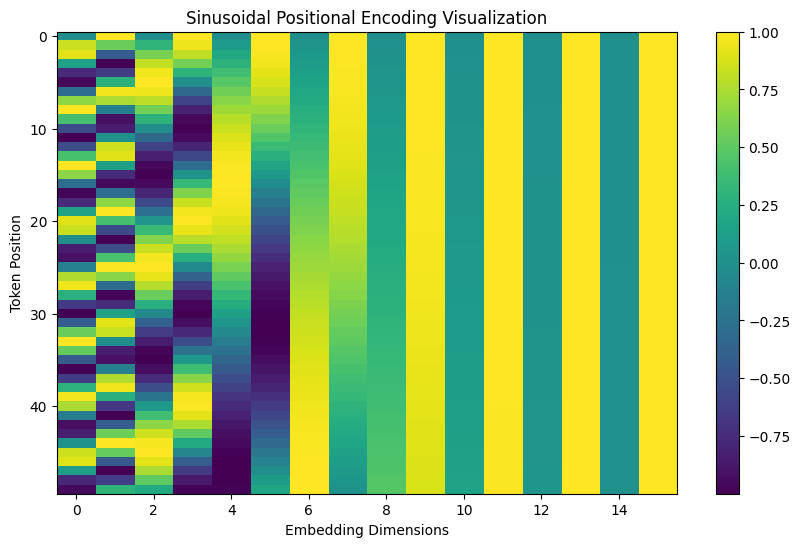

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_sinusoidal_positional_encoding(seq_len, d_model):
    """Generate sinusoidal positional encoding."""
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return torch.tensor(pe, dtype=torch.float32)

# Define sequence length and model dimension
seq_len = 50   # Number of positions (e.g., words in a sentence)
d_model = 16   # Embedding size (must be even)

# Get positional encoding
pos_encoding = get_sinusoidal_positional_encoding(seq_len, d_model)

# Plot positional encodings for visualization
plt.figure(figsize=(10, 6))
plt.imshow(pos_encoding.numpy(), aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Sinusoidal Positional Encoding Visualization")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Token Position")
plt.show()

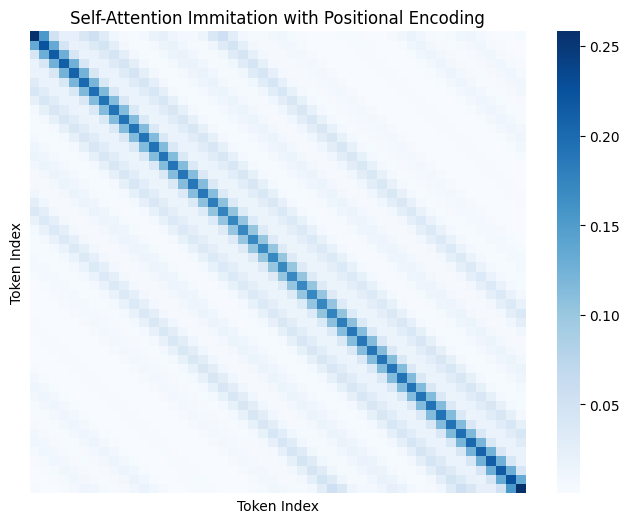

In [ ]:
seq_len = 50

encoded_tokens = pos_encoding[:seq_len, :]

# Simulate self-attention scores using dot product of encoded tokens
attention_scores = torch.matmul(encoded_tokens, encoded_tokens.T)

# Normalize attention scores
attention_scores = torch.nn.functional.softmax(attention_scores, dim=-1)

# Visualize attention scores
plt.figure(figsize=(8, 6))
sns.heatmap(attention_scores.numpy(), cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Self-Attention Immitation with Positional Encoding")
plt.xlabel("Token Index")
plt.ylabel("Token Index")
plt.show()


### RoPE — Rotary Positional Embeddings

**Интуиция:** каждую пару элементов вектора Q и K мы «поворачиваем» на угол, зависящий от позиции токена в последовательности. Чем дальше друг от друга два токена, тем больше разница углов поворота — и это естественным образом кодирует относительное расстояние между ними.

- ✔️ Применяются в модуле механизма внимания **на каждом слое**
- ✔️ Может работать с более длинными последовательностями ([YaRN](https://arxiv.org/abs/2309.00071))
- ✔️ Предпочтительный бейзлайн для выбора позиционных эмбэддингов


[**Annotated RoPE**](https://nn.labml.ai/transformers/rope/index.html)

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_8.png" width=700 />

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_9.png" width=700 />

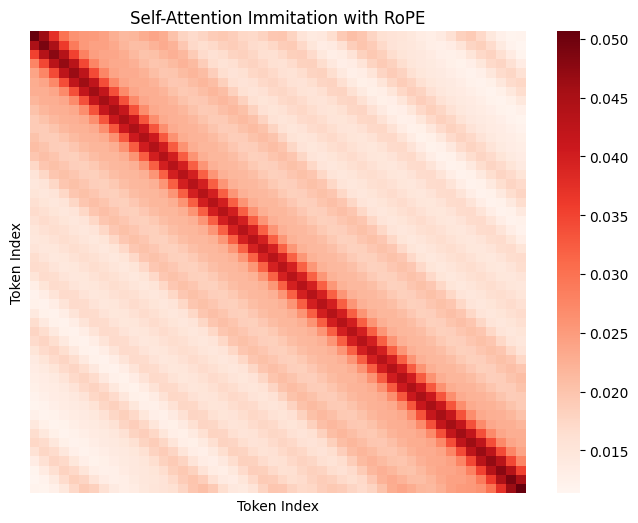

In [1]:
import math

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def apply_rope(q: torch.Tensor, k: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Apply Rotary Positional Embeddings (RoPE) to query and key vectors."""
    seq_len, d_model = q.shape
    theta = 10_000 ** (-torch.arange(0, d_model, 2).float() / d_model)

    position = torch.arange(seq_len).float().unsqueeze(1)
    theta = position * theta.unsqueeze(0)

    sin_theta = torch.sin(theta)
    cos_theta = torch.cos(theta)

    q1, q2 = q[..., 0::2], q[..., 1::2]
    k1, k2 = k[..., 0::2], k[..., 1::2]

    q_rotated = torch.cat([q1 * cos_theta - q2 * sin_theta, q1 * sin_theta + q2 * cos_theta], dim=-1)
    k_rotated = torch.cat([k1 * cos_theta - k2 * sin_theta, k1 * sin_theta + k2 * cos_theta], dim=-1)

    return q_rotated, k_rotated

seq_len = 50   # Number of positions (e.g., words in a sentence)
d_model = 64   # Embedding size (must be even)

# Одинаковый вектор Q=K во всех позициях — чтобы изолировать эффект RoPE
q = torch.rand(1, d_model).repeat(seq_len, 1)
k = q.clone()

q_rotated, k_rotated = apply_rope(q, k)

rope_attention_scores = torch.matmul(q_rotated, k_rotated.T) / math.sqrt(d_model)
rope_attention_scores = torch.nn.functional.softmax(rope_attention_scores, dim=-1)

plt.figure(figsize=(8, 6))
sns.heatmap(rope_attention_scores.numpy(), cmap="Reds", xticklabels=False, yticklabels=False)
plt.title("Self-Attention Immitation with RoPE")
plt.xlabel("Token Index")
plt.ylabel("Token Index")
plt.show()


### DroPE — Dropping Positional Embeddings

<img src="https://pub.sakana.ai/DroPE/assets/figures/drope.gif" width=700 />

**Paper:** [DroPE: Extending Context by Dropping Positional Embeddings](https://pub.sakana.ai/DroPE/) (2025)

**Проблема RoPE:** при экстраполяции на длины, превышающие обучающие, низкие частоты RoPE не завершают полный цикл — attention «ломается». Методы масштабирования (PI, NTK, YaRN) сжимают частоты, но при этом искажают семантические головы внимания.

**Идея DroPE:** использовать RoPE только как «строительные леса» при обучении, а затем убрать:

1. 🏗️ **Pretraining** — обучаем модель с RoPE (ускоряет обучение)
2. 🗑️ **Removal** — убираем позиционные эмбэддинги из всех слоёв
3. 🔧 **Recalibration** — дообучаем ~0.5–0.8% от бюджета pretraining

**Почему RoPE помогает при обучении:** градиенты при инициализации с RoPE значительно выше, чем без PE → модель быстрее учит позиционно-зависимые паттерны внимания.

**Результаты:**
- Needle-in-a-haystack на 2× контексте: значительно лучше RoPE-scaling
- Llama2-7B: SOTA на long-context QA с рекалибровкой всего 20B токенов (0.5% от 4T pretraining)

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/drope_niah.png" width=700 />

### Итого: позиционные эмбэддинги

| | Learned | Sinusoidal | RoPE | DroPE |
|---|---|---|---|---|
| Обучаемые | ✅ да | ❌ нет | ❌ нет | ❌ нет |
| Где | ➕ к входу | ➕ к входу | 🔄 в Q, K каждого слоя | 🗑️ убираются после обучения |
| Экстраполяция | 🔴 нет | 🟡 плохо | 🟡 с YaRN | 🟢 нативная |
| Тип позиции | абсолютная | абсолютная | относительная | — (нет PE) |
| Используется в | BERT, GPT-2 | Transformer | Llama, Mistral | Sakana AI |

### `scaled_dot_product_attention` в PyTorch

Начиная с PyTorch 2.0, FlashAttention доступен через `torch.nn.functional.scaled_dot_product_attention`:

In [ ]:
import torch
import torch.nn.functional as F

# Генерируем Q, K, V
batch_size, num_heads, seq_len, head_dim = 2, 8, 128, 64
q = torch.randn(batch_size, num_heads, seq_len, head_dim)
k = torch.randn(batch_size, num_heads, seq_len, head_dim)
v = torch.randn(batch_size, num_heads, seq_len, head_dim)

# Ручная реализация
def manual_attention(q: torch.Tensor, k: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """Ручная реализация scaled dot-product attention."""
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / (d_k ** 0.5)
    weights = torch.softmax(scores, dim=-1)
    return torch.matmul(weights, v)

# PyTorch (может использовать FlashAttention, если доступен)
out_pytorch = F.scaled_dot_product_attention(q, k, v)

# Ручная реализация
out_manual = manual_attention(q, k, v)

print(f"Результаты совпадают: {torch.allclose(out_pytorch, out_manual, atol=1e-6)}")
print(f"Размерность выхода: {out_pytorch.shape}")

---

## [HuggingFace](https://huggingface.co/)

Мы разобрали архитектуру трансформеров и способы сделать attention эффективнее. Теперь посмотрим, как работать с готовыми моделями на практике — для этого существует экосистема HuggingFace.

- [quicktour](https://huggingface.co/docs/transformers/quicktour)
- [training](https://huggingface.co/docs/transformers/training)

### Pipeline

In [ ]:
!pip install -q transformers

In [ ]:
from transformers import pipeline
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english)


Downloading:   0%|          | 0.00/629 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/255M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

In [ ]:
classifier.model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0): TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
       

In [ ]:
classifier("We are very happy to show you the 🤗 Transformers library.")

[{'label': 'POSITIVE', 'score': 0.9997795224189758}]

### Auto* Classes

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elemen

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer

Downloading:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/851k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

PreTrainedTokenizerFast(name_or_path='nlptown/bert-base-multilingual-uncased-sentiment', vocab_size=105879, model_max_len=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'})

In [ ]:
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

In [ ]:
classifier("Nous sommes très heureux de vous présenter la bibliothèque 🤗 Transformers.")


[{'label': '5 stars', 'score': 0.7272651791572571}]

### Training (Finetuning)


In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("yelp_review_full")
dataset["train"][100]


Reusing dataset yelp_review_full (/root/.cache/huggingface/datasets/yelp_review_full/yelp_review_full/1.0.0/13c31a618ba62568ec8572a222a283dfc29a6517776a3ac5945fb508877dde43)


  0%|          | 0/2 [00:00<?, ?it/s]

{'label': 0,
 'text': 'My expectations for McDonalds are t rarely high. But for one to still fail so spectacularly...that takes something special!\\nThe cashier took my friends\'s order, then promptly ignored me. I had to force myself in front of a cashier who opened his register to wait on the person BEHIND me. I waited over five minutes for a gigantic order that included precisely one kid\'s meal. After watching two people who ordered after me be handed their food, I asked where mine was. The manager started yelling at the cashiers for \\"serving off their orders\\" when they didn\'t have their food. But neither cashier was anywhere near those controls, and the manager was the one serving food to customers and clearing the boards.\\nThe manager was rude when giving me my order. She didn\'t make sure that I had everything ON MY RECEIPT, and never even had the decency to apologize that I felt I was getting poor service.\\nI\'ve eaten at various McDonalds restaurants for over 30 years. 

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_datasets = dataset.map(tokenize_function, batched=True)

Loading cached processed dataset at /root/.cache/huggingface/datasets/yelp_review_full/yelp_review_full/1.0.0/13c31a618ba62568ec8572a222a283dfc29a6517776a3ac5945fb508877dde43/cache-a9ff008ff2e851c3.arrow


  0%|          | 0/50 [00:00<?, ?ba/s]

In [ ]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(1000))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-cased", num_labels=5)

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at b

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="test_trainer",
    evaluation_strategy="epoch",
)


In [ ]:
import numpy as np
from datasets import load_metric

metric = load_metric("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.7/dist-packages/transformers/optimization.py:309: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  FutureWarning,
***** Running training *****
  Num examples = 1000
  Num Epochs = 3
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 375


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: ignored

## Итого: RNN vs Transformer

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/rnn_vs_transformer.png" width=900 />

| | RNN / LSTM / GRU | Transformer |
|---|---|---|
| **Обучение: форвард-пассы на последовательности длины `n`** | 🔴 `O(n)` последовательных шагов (нельзя параллелить по токенам) | 🟢 `O(1)` шагов — все позиции обсчитываются параллельно |
| **Обучение: compute** | 🟢 `O(n · d²)` | 🟡 `O(n² · d + n · d²)` — квадратично по длине |
| **Обучение: память** | 🟢 `O(n · d)` | 🔴 `O(n² + n · d)` (без FlashAttention) |
| **Инференс (на 1 новый токен)** | 🟢 `O(d²)`, скрытое состояние фиксированного размера | 🟡 `O(n · d)` с KV-cache; `O(n² · d)` без |
| **Память при инференсе** | 🟢 `O(d)` (одно состояние) | 🔴 `O(n · d · L)` KV-cache растёт с контекстом |
| **Длинный контекст** | 🔴 забывает (vanishing gradients) | 🟢 прямой доступ к любому токену |
| **Масштабирование** | 🔴 плохо масштабируется: sequential depth, сложно утилизировать GPU | 🟢 отлично ложится на GPU/TPU: батч × голов × позиций параллельно |
| **Параллелизм на батче** | 🟡 есть, но шаг по времени всё равно последовательный | 🟢 полный параллелизм |
| **Интерпретируемость** | 🔴 непрозрачное скрытое состояние | 🟡 attention weights можно смотреть |
| **Стриминг / онлайн-инференс** | 🟢 естественный, `O(1)` на токен | 🟡 требует KV-cache, растущий с длиной |
| **SOTA на 2025** | редко (спец. случаи: edge, стриминг) | ✅ доминирует в NLP, CV (ViT), Speech, Multimodal |

> **Ключевая идея:** trade-off — трансформер меняет **последовательность по времени** на **параллелизм + квадратичную сложность по длине**. Для обучения на GPU это выгодный размен; для инференса в длинном контексте — появляются оптимизации (KV-cache, FlashAttention, Sliding Window, линейные варианты).

> Попытки вернуть `O(n)` обучения **и** `O(1)` инференс-памяти — Mamba / SSM, RWKV, линейные трансформеры.

## Блиц

### NLP

#### ❓ **Вопрос**: что такое эмбэддинг?

<details>

<summary><strong>Ответ</strong></summary>

Эмбэддингом обычно называют векторное представление какой-то сущности. Бывают эмбэддинги слов, предложений, документов, картинок, аудио, пользователей, товаров и т.д.

</details>

#### ❓ **Вопрос**: чем эмбэддинги `Word2Vec` или `FastText` отличаются от эмбэддингов `RNN`, `Transformer`? *(recap прошлого семинара)*

<details>

<summary><strong>Ответ</strong></summary>

RNN, Transformer позволяют получить эмбэддинг слова в текущем контексте и в зависимости от контекста эмбэддинг может быть разным. В W2V, FT эмбэддинги слов статичны.

</details>

#### ❓ **Вопрос**: чем LSTM/RNN лучше/хуже для задачи POS-tagging'а, чем MLP классификатор?

<details>

<summary><strong>Ответ</strong></summary>

В MLP нет никакой информации о контексте. RNN'ки учитывают его за счет `hidden_state`'а.</br>
Можно перед MLP добавить слой `Attention` для решения этой проблемы, но в этом случае мы получим практически трансформер.

</details>

#### ❓ **Вопрос**: зачем нужен токенизатор?

<details>

<summary><strong>Ответ</strong></summary>

Токенизатор отвечает за задачу разбиения строки на токены (или если упрощать, то на части слов) и преобразование каждого токена в целое число.</br>

Если упрощенно, интерфейс токенизатора можно было бы представить так:</br>

```python
def tokenize(text: str) -> List[int]:
    pass
```

</details>

### RNN

#### ❓ **Вопрос**: какие проблемы есть у RNN?

<details>

<summary><strong>Ответ</strong></summary>

- Долго обучается и вычисляется (а почему?)</br>
- Затухающие градиенты</br>
- Плохо работают с долгосрочными зависимостями (помнят лишь небольшой контекст)</br>
- Контекст учитывается только слева направо</br>

</details>

#### ❓ **Вопрос**: как проблемы RNN решаются в LSTM?

<details>

<summary><strong>Ответ</strong></summary>

LSTM только пытается решить проблему работы с длинным контекстом. Для этого вводится cell state, через который легко могут течь градиенты, т.к. в нем нет сигмоиды, которая бы могла приводить к затухающим градиентам. И кроме градиентов, через cell state в прямом направлении тоже лучше распространяется информация.

</details>

#### ❓ **Вопрос**: чем GRU отличается от LSTM?

<details>

<summary><strong>Ответ</strong></summary>

`GRU` имеет меньше параметров чем `LSTM` за счет меньшего количества гейтов. В `GRU` отказались от cell state.

</details>

#### ❓ **Вопрос**: чем `LSTM(..., bidirectional=True)` отличается от `LSTM(..., num_layers=2)`?

<details>

<summary><strong>Ответ</strong></summary>

`LSTM(..., bidirectional=True)` — сначала составляет эмбэддинги слева направо, а потом справа налево. В итоге получается 2 набора эмбэддингов, которые посчитали в разных направлениях.</br>
Генерация с разных сторон позволяет лучше учитывать локальный контекст в начале длинной последовательности при обратном проходе.</br>
По правде говоря, это просто костыль, попытка решить фундаментальную проблему плохой адаптируемости RNN к работе с длинными последовательностями.</br>

`LSTM(..., num_layers=2)` — оба набора эмбэддингов генерируются слева направо.

</details>

#### ❓ **Вопрос**: можно ли применить механизм внимания к RNN? Если да, то зачем тогда трансформеры вообще?

<details>

<summary><strong>Ответ</strong></summary>

Применить можно — поверх RNN эмбэддингов — так даже делали какое-то время.</br>

Применение механизма внимания к RNN делает их более выразительными. Но не решает многих проблем RNN: долгое и нестабильное обучение (без возможности распараллеливания).</br>

Фундаментальная статья Attention Is All You Need потому и называется так, что оказалось, что тушка RNN не нужна.

</details>

### Attention

#### ❓ **Вопрос**: в чем различие `RNN + Attention` vs `Vanilla RNN`? Какую проблему решает механизм внимания? Чем мы жертвуем для решения этой проблемы?

<details>

<summary><strong>Ответ</strong></summary>

Нет bottleneck одного вектора для Attention RNN. Жертвуем вычислительными ресурсами.

</details>

#### ❓ **Вопрос**: зачем нужен ➡️**Scaled**⬅️ Dot-Product Attention?

<details>

<summary><strong>Ответ</strong></summary>

Скейл (деление на корень из размерности) позволяет лучше протекать градиентам.</br>

Если не скейлить, то числа под софтмаксом получаются большими после перемножения матриц.</br>
Большие по модулю числа в софтмаксе могут привести к сильному и значительному перевешиванию одного из чисел. Из-за чего градиенты по остальным индексам не потекут.</br>

**Почему именно $\sqrt{d_k}$, а не $d_k$ или что-то ещё?**

Посмотрим на скалярное произведение $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$.

Предположим, что при инициализации компоненты $q_i$ и $k_i$ независимы, имеют нулевое среднее и дисперсию $1$:

$$\mathbb{E}[q_i k_i] = 0, \quad \mathrm{Var}(q_i k_i) = 1.$$

Тогда по свойству суммы независимых случайных величин:

$$\mathrm{Var}(q \cdot k) = \sum_{i=1}^{d_k} \mathrm{Var}(q_i k_i) = d_k, \quad \mathrm{std}(q \cdot k) = \sqrt{d_k}.$$

То есть типичный масштаб логитов растёт как $\sqrt{d_k}$. Деление на $\sqrt{d_k}$ возвращает их к дисперсии $1$ — независимо от того, какую размерность голов мы выбрали ($d_k = 32, 64, 128, \dots$).

**Почему это важно именно для софтмакса:**

- Если поделить на $d_k$ (слишком сильный скейл) — при больших $d_k$ логиты будут близки к нулю, софтмакс станет почти равномерным, модель не сможет «заострять» внимание.
- Если не делить вовсе — при больших $d_k$ логиты распухают как $\sqrt{d_k}$, софтмакс насыщается (один вес ≈ 1, остальные ≈ 0), и градиенты $\frac{\partial \mathrm{softmax}}{\partial x_i} = p_i(1 - p_i)$ затухают.
- $\sqrt{d_k}$ — единственный масштаб, при котором дисперсия логитов **не зависит от $d_k$**, и поведение софтмакса согласовано между разными конфигурациями модели.

https://ai.stackexchange.com/a/42197

```python
import torch
import torch.nn as nn
sm = nn.Softmax(dim=0)

# предположим, что мы посчитали q @ k.T для размерности 256
# и в результате мы могли получить числа с СКО 16
attention_qkt = torch.tensor([ -16.0, -8.0, 0.0, 8.0, 16.0 ])

# not scaled softmax
sm( attention_qkt ) # tensor([1.2660e-14, 3.7739e-11, 1.1250e-07, 3.3535e-04, 9.9966e-01])

# scaled softmax
sm( attention_qkt / 16 ) # tensor([0.0580, 0.0956, 0.1577, 0.2600, 0.4287])
```

</details>

#### ❓ **Вопрос**: чем MHA (Multi-Head-Attention) лучше SHA (Single-Head-Attention)?

<details>

<summary><strong>Ответ</strong></summary>

|                        | MHA       | SHA      |
|------------------------|-----------|----------|
| Матричные операции     | Больше    | Меньше   |
| Количество параметров  | Примерно  | Одинаково|
| Скорость вычислений    | Примерно  | Одинаково (т.к. MHA параллелятся вычисления) |
| Выразительность        | Больше    | Меньше   |

</details>

### Transformers

#### ❓ **Вопрос**: сколько раз надо запустить Transformer Encoder, чтобы получить эмбэддинг последовательности для одного батча?

<details>

<summary><strong>Ответ</strong></summary>

1

</details>

#### ❓ **Вопрос**: сколько раз надо запустить Decoder, чтобы сгенерировать последовательность длины `M`, если длина исходной последовательности `N`?

<details>

<summary><strong>Ответ</strong></summary>

M

</details>

#### ❓ **Вопрос**: сколько раз нужно запустить Decoder в процессе обучения?

<details>

<summary><strong>Ответ</strong></summary>

1

</details>

#### ❓ **Вопрос**: какие типы механизма внимания есть в трансформерах (отдельно в `Encoder`, отдельно в `Decoder`)?

<details>

<summary><strong>Ответ</strong></summary>

- Encoder — используется только self-attention</br>
- Decoder — используется self-attention + cross-attention</br>

</details>

#### ❓ **Вопрос**: какие типы масок есть в трансформерах?

<details>

<summary><strong>Ответ</strong></summary>

- Causal mask — используется в **self-attention декодера** для того, чтобы избежать заглядывания на будущие токены</br>
- Padding mask — для маскирования токенов паддинга (используется и в энкодере, и в декодере)</br>

</details>

#### ❓ **Вопрос**: зависит ли количество параметров от длины последовательности в `Transformer`? А в `RNN`?

<details>

<summary><strong>Ответ</strong></summary>

Нет, не зависит ни для одной из архитектур. Но для трансформеров от длины последовательности зависит размер KV-Cache

</details>

#### ❓ **Вопрос**: зачем нужны позиционные эмбэддинги?

<details>

<summary><strong>Ответ</strong></summary>

Механизм внимания никак не учитывает порядок токенов.</br>
Т.к. при умножении можно переставить соответствующие строки и столбцы в матрицах и результат attention не изменится. Позиционные эмбэддинги должны привнести смещение для соответствующих токенов как раз для того, чтобы если это необходимо, модель могла их использовать.

</details>

---

## Efficient Attention

Мы разобрались, как устроен attention и позиционные эмбэддинги. Но у стандартного внимания есть проблема — квадратичная сложность по длине последовательности. Посмотрим, какие подходы существуют для её решения.

### Complexity

Стандартный attention имеет сложность $O(N^2)$ по длине последовательности — и по вычислениям, и по памяти. На практике узкое место часто не сами вычисления, а **пропускная способность памяти GPU**: чтение/запись матрицы внимания $N \times N$ из/в HBM (High Bandwidth Memory) занимает больше времени, чем арифметические операции над ней.

#### Dimensions:

$$ \text{Attention}(\underset{\mathbb{R}^{n \times d_k}}{Q}, \underset{\mathbb{R}^{n \times d_k}}{K}, \underset{\mathbb{R}^{n \times d_v}}{V}) = \underset{\mathbb{R}^{n \times n}}{\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)} \underset{\mathbb{R}^{n \times d_v}}{V}
$$

Возможные решения:

1. **Инженерные трюки** - [FlashAttention](https://github.com/Dao-AILab/flash-attention/), [HIP Attention](https://github.com/DeepAuto-AI/hip-attention/), [FlashMLA](https://github.com/deepseek-ai/FlashMLA)

1. **Разреженные представления внимания** - [BigBird](https://arxiv.org/abs/2007.14062), [Longformer](https://arxiv.org/pdf/2004.05150)

2. **Линейные алгоритмы вычисления внимания** - [Performer](https://arxiv.org/abs/2009.14794), [Linformer](https://arxiv.org/abs/2006.04768)



### [FlashAttention](https://github.com/Dao-AILab/flash-attention)

Интересные факты:

- [Включено](https://pytorch.org/blog/pytorch2-2/) в ядро Pytorch из коробки — [**scaled_dot_product_attention**](https://pytorch.org/docs/2.2/generated/torch.nn.functional.scaled_dot_product_attention.html)
- Пилит один человек, пользуется вся индустрия

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_10.png" width=400 />

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_11.png" width=400 />

### Сравнение

**Идея:** За счет эффективной работы с памятью, можно увеличить количество вычислений, но сэкономить общее время вычисления, т.к. часто узкое место — это именно загрузка/запись в память.


### EagerAttention

**Теоретическая вычислительная сложность:** $ O(N^2) $

**Эффективная вычислительная сложность:** $ O(N^2) $

**Сложность по памяти:** $ O(N^2) $

### FlashAttention

**Теоретическая вычислительная сложность:** $ O(N^2) $

**Эффективная вычислительная сложность:** $ O(N) $ ✅

**Сложность по памяти:** $ O(N) $ ✅

### [BigBird](https://arxiv.org/abs/2007.14062) (transformer-encoder)

**Идея:** Модифицируем маску для вычисления внимания.

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_12.png" width=400 />

### Linformer

**Идея:** Можно сделать "трюк" в вычислении матрицы внимания $Q$, $K$ для того, чтобы уменьшить вычислительную сложность внимания.

### Сложность матричного умножения:

#### Eager Attention

$d$ — скрытая размерность

$N$ — размерность длины последовательности

$$ Q_{N \times d} \cdot  K_{N \times d}^T = Attention_{N \times N} $$

$$ Q_{N \times d} \cdot  K_{d \times N} = Attention_{N \times N} $$


Вычислительная сложность: $O(N \times N \times d) = O(N^2 \cdot d)$

#### Linformer Attention

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_13.png" width=400 />

---

### 🎁 Бонус: [RMT (Recurrent Memory Transformer)](https://arxiv.org/abs/2207.06881)

Идея: объединить RNN и Transformer — рекуррентно обрабатывать сегменты последовательности трансформером.

[Github](https://github.com/booydar/LM-RMT)

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/09_rnn_transformer/static/img_14.png" width=400 />

### Материалы по RNN

#### Задача POS-tagging

В отдельном [**ноутбуке**](https://colab.research.google.com/drive/1DMydkEt3mg8MagsMoitWHDUUWcjRa9Cd?usp=sharing)

Оригинальный [туториал](https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html)

- [Memorization in RNNs](https://distill.pub/2019/memorization-in-rnns/)
- [Illustrated Guide to LSTM's and GRU's: A step by step explanation](https://towardsdatascience.com/illustrated-guide-to-lstms-and-gru-s-a-step-by-step-explanation-44e9eb85bf21)

### Материалы по трансформерам

Код с комментариями и подробным разбором. Хотя имхо код не самый качественный, общую идею уловить можно.
http://nlp.seas.harvard.edu/2018/04/03/attention.html

https://jalammar.github.io/illustrated-transformer/

#### Войта

- [seq2seq_and_attention](https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html)
- [the-story-of-heads](https://github.com/lena-voita/the-story-of-heads)

#### HF Course

https://huggingface.co/course/


---

## Дополнительные вопросы для самопроверки

#### ❓ **Вопрос**: чем `RNN(..., bidirectional=True)` отличается от `RNN(..., num_layers=2)`?

<details>

<summary><strong>Ответ</strong></summary>

Эта механика не зависит от конкретной реализации RNN/LSTM/GRU — везде работает одинаково. Поэтому ответ на этот вопрос такой же как и на предыдущий.

</details>

#### ❓ **Вопрос**: чем слой первичных эмбэддингов (неконтекстных) в трансформерах отличается от первичных эмбэддингов в RNN?

<details>

<summary><strong>Ответ</strong></summary>

Ничем — это один и тот же слой `nn.Embeddings`, используется тоже абсолютно одинаково.

</details>

#### ❓ **Вопрос**: сколько раз запускается RNN-декодер в процессе **обучения** (seq2seq задача, длина входа $N$, длина выхода $M$)?

<details>

<summary><strong>Ответ</strong></summary>

1 раз — при обучении используется teacher forcing: на каждом шаге подаётся правильный токен, и всю последовательность можно обработать за один проход.</br>
Энкодер тоже запускается 1 раз. Итого: 2 прохода.

</details>

#### ❓ **Вопрос**: сколько раз запускается RNN-декодер в процессе **инференса** (генерации) для последовательности длины $M$?

<details>

<summary><strong>Ответ</strong></summary>

$M$ раз — при инференсе генерация авторегрессивная: на каждом шаге подаётся предыдущий сгенерированный токен.</br>
Энкодер запускается 1 раз. Итого: $1 + M$ проходов.

</details>

#### ❓ **Вопрос**: где и как еще можно применить механизм внимания?

<details>

<summary><strong>Ответ</strong></summary>

Где угодно! Картинки, звук, временные ряды и т.д.

</details>

---

## Домашки

- **rnn-attention** — реализация механизма внимания поверх RNN. Обратите внимание на размерности тензоров при конкатенации скрытых состояний и вычислении весов внимания.
- **transformer-attention** — реализация механизма внимания в трансформере. Типичные ошибки: неправильная маска (causal mask), забытое масштабирование на $\sqrt{d_k}$, неверные размерности при multi-head split.

**На что обратить внимание:**
- Внимательно следите за размерностями тензоров на каждом шаге
- Проверяйте, что маски применяются **до** softmax, а не после
- Используйте `assert` для проверки размерностей в процессе отладки